In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

In [2]:
import joblib

SELECTED_FEATURES = ['HighBP', 'GenHlth', 'HighChol', 'Age_BMI_Risk', 'CholCheck',
                     'HvyAlcoholConsump', 'BMI', 'PhysActivity', 'Smoker']
BEST_THRESHOLD = 0.45  # update sesuai hasil threshold tuning

df_test = pd.read_csv("/content/data_test_unscaled.csv")

X_test_raw = df_test[SELECTED_FEATURES].values.astype('float32')
y_test     = df_test['label'].values.astype('float32')

# Scale pakai scaler yang sama dari training
scaler = joblib.load('/content/scaler_inference.pkl')
X_test = scaler.transform(X_test_raw).astype('float32')

print("=== TEST SET INFO ===")
print(f"Shape     : {X_test.shape}")
print(f"Label 0   : {(y_test == 0).sum()}")
print(f"Label 1   : {(y_test == 1).sum()}")
print(f"Threshold : {BEST_THRESHOLD}")

=== TEST SET INFO ===
Shape     : (47949, 9)
Label 0   : 40964
Label 1   : 6985
Threshold : 0.45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — REBUILD MODEL & LOAD WEIGHTS
# Arsitektur ini HARUS sama persis dengan Capstone_AI_Final_xai.ipynb
# ─────────────────────────────────────────────────────────────────────────────

class DenseBlock(keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.2, use_residual=False, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate
        self.use_residual = use_residual

        # Dense tanpa aktivasi dulu — biar BatchNorm jalan sebelum ReLU (Pre-Activation)
        self.dense   = layers.Dense(units, activation=None)
        self.bn      = layers.BatchNormalization()
        self.relu    = layers.Activation('relu')
        self.dropout = layers.Dropout(dropout_rate)

        # Projection untuk residual — juga pre-activation, tanpa bias
        if use_residual:
            self.proj    = layers.Dense(units, activation=None, use_bias=False)
            self.proj_bn = layers.BatchNormalization()
        else:
            self.proj    = None
            self.proj_bn = None

    def call(self, x, training=False):
        out = self.dense(x)
        out = self.bn(out, training=training)   # BatchNorm sebelum ReLU
        out = self.relu(out)
        out = self.dropout(out, training=training)

        if self.use_residual and self.proj is not None:
            shortcut = self.proj(x)
            shortcut = self.proj_bn(shortcut, training=training)
            out = out + shortcut
        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            'units'       : self.units,
            'dropout_rate': self.dropout_rate,
            'use_residual': self.use_residual,
        })
        return config


class HealthClassifier(keras.Model):
    def __init__(self, input_dim, **kwargs):
        super().__init__(**kwargs)
        self.block1 = DenseBlock(512, dropout_rate=0.30, use_residual=False, name='block1')
        self.block2 = DenseBlock(256, dropout_rate=0.20, use_residual=True,  name='block2')
        self.block3 = DenseBlock(128, dropout_rate=0.10, use_residual=True,  name='block3')
        self.block4 = DenseBlock(64,  dropout_rate=0.05, use_residual=False, name='block4')
        self.out    = layers.Dense(1, activation='sigmoid')

    def call(self, x, training=False):
        x = self.block1(x, training=training)
        x = self.block2(x, training=training)
        x = self.block3(x, training=training)
        x = self.block4(x, training=training)
        return self.out(x)

    def get_config(self):
        return super().get_config()


INPUT_DIM = len(SELECTED_FEATURES)  # 9
model     = HealthClassifier(input_dim=INPUT_DIM)
_         = model(tf.zeros((2, INPUT_DIM)), training=False)
model.load_weights("/content/best_weights.weights.h5")
print(f"\nModel loaded — {model.count_params():,} params")



Model loaded — 346,881 params


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — PREDIKSI
# ─────────────────────────────────────────────────────────────────────────────

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_test)
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

all_probs = []
for X_batch in test_dataset:
    probs = model(X_batch, training=False)
    all_probs.extend(probs.numpy().flatten())

all_probs  = np.array(all_probs)
all_preds  = (all_probs >= BEST_THRESHOLD).astype(int)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — CONFUSION MATRIX + CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test, all_preds)
TN, FP, FN, TP = cm.ravel()

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(f"  TN (benar non-diabetes) : {TN:>6}")
print(f"  FP (salah diabetes)     : {FP:>6}")
print(f"  FN (miss diabetes!)     : {FN:>6}")
print(f"  TP (benar diabetes)     : {TP:>6}")

print("\n" + "=" * 60)
print("RATIO FN vs TP")
print("=" * 60)
ratio = FN / TP if TP > 0 else float('inf')
print(f"  FN : {FN}")
print(f"  TP : {TP}")
print(f"  Ratio FN/TP : {ratio:.2f}")
if ratio > 1:
    print(f"  ⚠️  Model miss {ratio:.1f}x lebih banyak daripada yang berhasil ditangkap")
else:
    print(f"  ✅ Model berhasil tangkap lebih banyak daripada yang di-miss")

print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT (threshold={BEST_THRESHOLD})")
print("=" * 60)
print(classification_report(
    y_test, all_preds,
    target_names=['Non-Diabetes (0)', 'Diabetes (1)']
))


CONFUSION MATRIX
  TN (benar non-diabetes) :  24992
  FP (salah diabetes)     :  15972
  FN (miss diabetes!)     :    967
  TP (benar diabetes)     :   6018

RATIO FN vs TP
  FN : 967
  TP : 6018
  Ratio FN/TP : 0.16
  ✅ Model berhasil tangkap lebih banyak daripada yang di-miss

CLASSIFICATION REPORT (threshold=0.45)
                  precision    recall  f1-score   support

Non-Diabetes (0)       0.96      0.61      0.75     40964
    Diabetes (1)       0.27      0.86      0.42      6985

        accuracy                           0.65     47949
       macro avg       0.62      0.74      0.58     47949
    weighted avg       0.86      0.65      0.70     47949



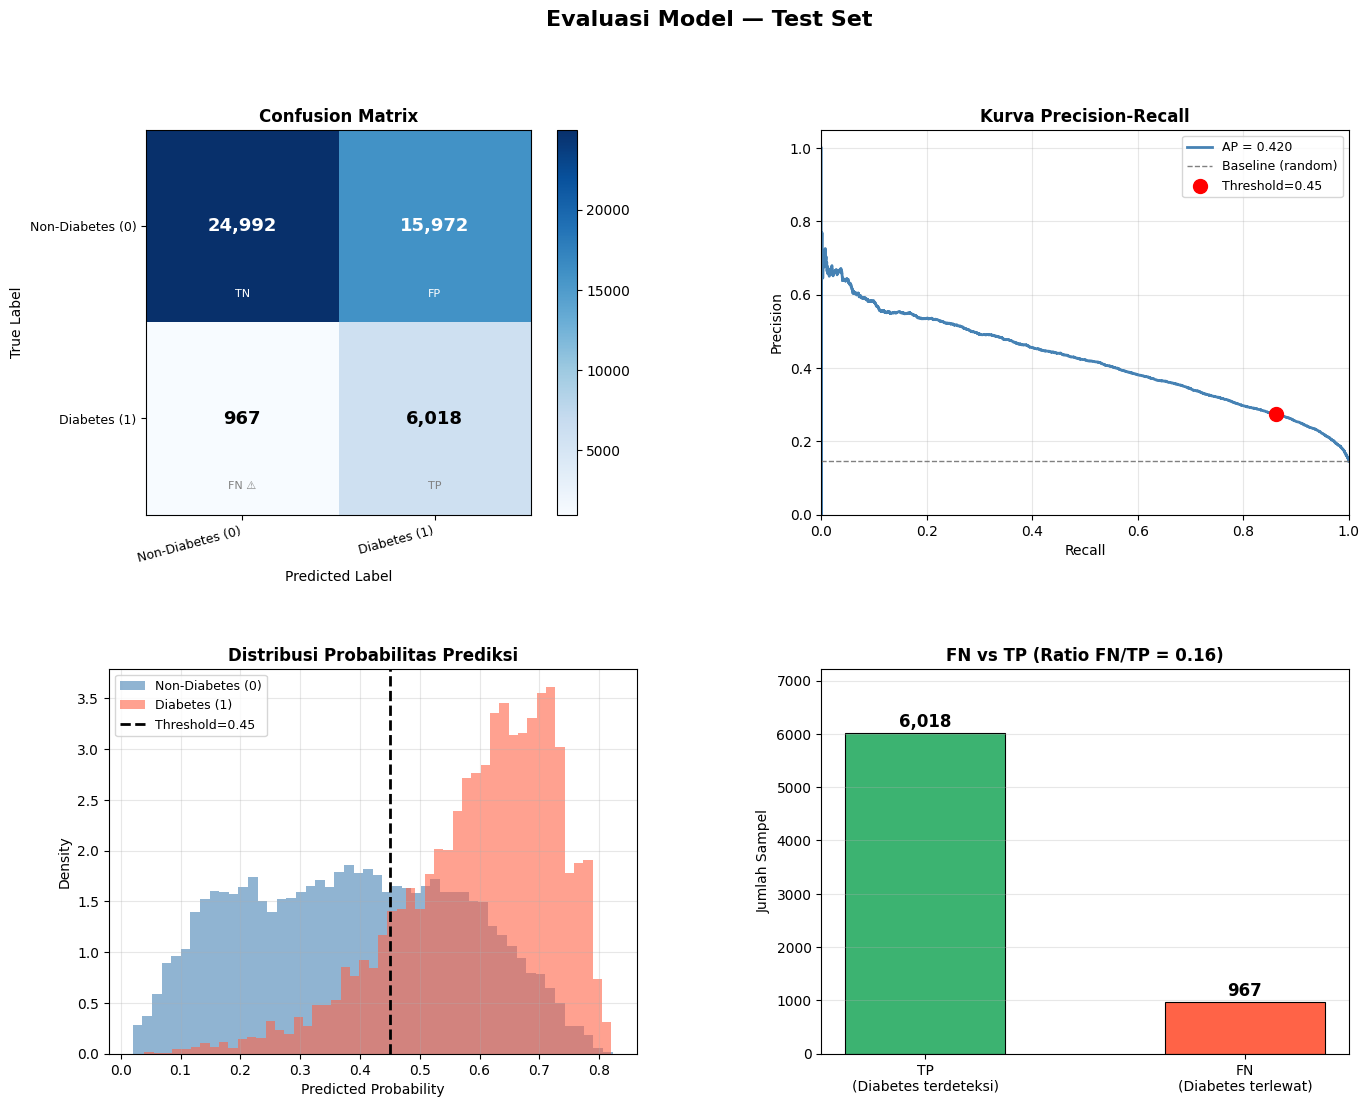


✅ Plot tersimpan → /content/evaluasi_test_set.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — VISUALISASI (4 plot sekaligus)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Evaluasi Model — Test Set', fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Confusion Matrix Heatmap ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
im  = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax1)

classes    = ['Non-Diabetes (0)', 'Diabetes (1)']
tick_marks = [0, 1]
ax1.set_xticks(tick_marks)
ax1.set_yticks(tick_marks)
ax1.set_xticklabels(classes, rotation=15, ha='right', fontsize=9)
ax1.set_yticklabels(classes, fontsize=9)

thresh_cm = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i, j]:,}',
                 ha='center', va='center', fontsize=13, fontweight='bold',
                 color='white' if cm[i, j] > thresh_cm else 'black')

ax1.set_xlabel('Predicted Label', fontsize=10)
ax1.set_ylabel('True Label', fontsize=10)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Annotasi TN/FP/FN/TP
labels_cm = [['TN', 'FP'], ['FN ⚠️', 'TP']]
for i in range(2):
    for j in range(2):
        ax1.text(j, i + 0.35, labels_cm[i][j],
                 ha='center', va='center', fontsize=8,
                 color='white' if cm[i, j] > thresh_cm else 'gray')

# ── Plot 2: Kurva Precision-Recall ────────────────────────────────────────────
ax2       = fig.add_subplot(gs[0, 1])
precision, recall, thresholds = precision_recall_curve(y_test, all_probs)
ap_score  = average_precision_score(y_test, all_probs)

ax2.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap_score:.3f}')
ax2.axhline(y=(y_test == 1).mean(), color='gray', linestyle='--', lw=1, label='Baseline (random)')

# Tandai threshold saat ini
idx = np.argmin(np.abs(thresholds - BEST_THRESHOLD))
ax2.scatter(recall[idx], precision[idx], color='red', s=100, zorder=5,
            label=f'Threshold={BEST_THRESHOLD}')

ax2.set_xlabel('Recall', fontsize=10)
ax2.set_ylabel('Precision', fontsize=10)
ax2.set_title('Kurva Precision-Recall', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3)

# ── Plot 3: Distribusi Probabilitas Prediksi ──────────────────────────────────
ax3         = fig.add_subplot(gs[1, 0])
probs_neg   = all_probs[y_test == 0]
probs_pos   = all_probs[y_test == 1]

ax3.hist(probs_neg, bins=50, alpha=0.6, color='steelblue', label='Non-Diabetes (0)', density=True)
ax3.hist(probs_pos, bins=50, alpha=0.6, color='tomato',    label='Diabetes (1)',     density=True)
ax3.axvline(x=BEST_THRESHOLD, color='black', linestyle='--', lw=2, label=f'Threshold={BEST_THRESHOLD}')

ax3.set_xlabel('Predicted Probability', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.set_title('Distribusi Probabilitas Prediksi', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Plot 4: FN vs TP Bar Chart ────────────────────────────────────────────────
ax4      = fig.add_subplot(gs[1, 1])
bars     = ax4.bar(['TP\n(Diabetes terdeteksi)', 'FN\n(Diabetes terlewat)'],
                   [TP, FN],
                   color=['mediumseagreen', 'tomato'],
                   edgecolor='black', linewidth=0.8, width=0.5)

for bar, val in zip(bars, [TP, FN]):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

ax4.set_ylabel('Jumlah Sampel', fontsize=10)
ax4.set_title(f'FN vs TP (Ratio FN/TP = {ratio:.2f})', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, max(TP, FN) * 1.2)

plt.savefig('/content/evaluasi_test_set.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot tersimpan → /content/evaluasi_test_set.png")